# Optimización de Portafolio — Modelo de Markowitz

Aplicación de la Teoría Moderna de Portafolios (Markowitz, 1952) a 9 acciones del IPSA distribuidas en 5 sectores, con datos de cierre diario Mayo 2024 – Mayo 2026.

| Sector | Acciones |
|---|---|
| Retail | FALABELLA, CENCOSUD |
| Energía | COPEC, ENELCHILE |
| Banca | BSANTANDER, BCI |
| Minería / Forestal | CAP, CMPC |
| Utilities | AGUAS-A |

**Objetivo:** encontrar la combinación de pesos que maximice el Sharpe ratio, trazar la frontera eficiente completa y comparar el resultado contra un benchmark pasivo (ETF ECH). Se usan dos enfoques complementarios: simulación de Monte Carlo y optimización analítica con `scipy.optimize`.

In [147]:
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as sop

## 1. Carga de datos

Se descargan 2 años de precios de cierre diarios para las 9 acciones usando Yahoo Finance. Los retornos diarios se calculan como variación porcentual entre cierres consecutivos. La matriz de covarianza captura cómo se mueven conjuntamente los activos — insumo fundamental del modelo de Markowitz.

### Exploración inicial del universo

Se calculan los retornos diarios, los retornos medios por activo y la matriz de covarianza. Estos tres insumos son los únicos que requiere el modelo de Markowitz para construir y optimizar portafolios.

In [148]:
lista_nombre_acciones = ["AGUAS-A.SN", "BCI.SN", "BSANTANDER.SN", "CAP.SN", "CENCOSUD.SN", "CMPC.SN", "COPEC.SN","ENELCHILE.SN", "FALABELLA.SN"]
datos_brutos_acciones = yf.download(tickers = lista_nombre_acciones, period = "2y")
datos_ech = yf.download(tickers= "ECH", period= "2y")
valores_cierre = datos_brutos_acciones["Close"]
cierre_ech = datos_ech["Close"]

[*********************100%***********************]  9 of 9 completed
[*********************100%***********************]  1 of 1 completed


In [149]:
retornos_diarios = valores_cierre.pct_change()
vector_pesos = np.array([1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9])

In [150]:
retornos_medios = retornos_diarios.mean()
retorno_portafolio = np.dot(retornos_medios, vector_pesos)
print(retorno_portafolio)


0.0006406514628113025


In [151]:
retornos_medios


Ticker
AGUAS-A.SN       0.000684
BCI.SN           0.001859
BSANTANDER.SN    0.001179
CAP.SN           0.000152
CENCOSUD.SN      0.000458
CMPC.SN         -0.000967
COPEC.SN        -0.000222
ENELCHILE.SN     0.000969
FALABELLA.SN     0.001653
dtype: float64

In [152]:
covarianza_portafolio = retornos_diarios.cov()
covarianza_portafolio


Ticker,AGUAS-A.SN,BCI.SN,BSANTANDER.SN,CAP.SN,CENCOSUD.SN,CMPC.SN,COPEC.SN,ENELCHILE.SN,FALABELLA.SN
Ticker,,,,,,,,,
AGUAS-A.SN,0.000151,0.000055,0.000045,0.000019,0.000032,0.000053,0.000040,0.000034,0.000040
BCI.SN,0.000055,0.000253,0.000101,0.000050,0.000073,0.000097,0.000088,0.000067,0.000108
BSANTANDER.SN,0.000045,0.000101,0.000158,0.000040,0.000068,0.000074,0.000068,0.000072,0.000094
CAP.SN,0.000019,0.000050,0.000040,0.000276,0.000055,0.000094,0.000074,0.000049,0.000066
CENCOSUD.SN,0.000032,0.000073,0.000068,0.000055,0.000279,0.000098,0.000067,0.000076,0.000101
CMPC.SN,0.000053,0.000097,0.000074,0.000094,0.000098,0.000298,0.000143,0.000055,0.000111
COPEC.SN,0.000040,0.000088,0.000068,0.000074,0.000067,0.000143,0.000226,0.000062,0.000091
ENELCHILE.SN,0.000034,0.000067,0.000072,0.000049,0.000076,0.000055,0.000062,0.000203,0.000094
FALABELLA.SN,0.000040,0.000108,0.000094,0.000066,0.000101,0.000111,0.000091,0.000094,0.000289


## 2. Función de evaluación de portafolio

Para cualquier vector de pesos , se calculan tres métricas:

- **Retorno esperado:** producto punto entre pesos y retornos medios diarios
- **Varianza:** forma cuadrática  sobre la matriz de covarianza
- **Volatilidad:** raíz cuadrada de la varianza
- **Sharpe simplificado:** retorno / volatilidad (sin tasa libre de riesgo)

Esta función es el núcleo de ambos métodos de optimización. A modo de referencia, se evalúa el portafolio de pesos iguales (1/9 por acción) como punto de comparación inicial.

In [153]:
varianza = np.dot(vector_pesos, np.dot(covarianza_portafolio, vector_pesos))
dst = np.sqrt(varianza)
print(dst)
sharpe = retorno_portafolio/dst
print(sharpe)

0.009454394044880311
0.06776229759095184


## 3. Simulación de Monte Carlo

Se generan 10.000 portafolios con pesos aleatorios normalizados para que sumen 1. Para cada uno se calcula retorno, volatilidad y Sharpe. El resultado es una nube de puntos en el espacio riesgo-retorno que visualiza el universo de portafolios alcanzables.

Este método es exploratorio: no garantiza el óptimo global, pero permite visualizar la estructura del problema antes de aplicar optimización analítica.

In [154]:
def funcion_definicon(vector_pesos):
    retorno_portafolio = np.dot(retornos_medios, vector_pesos)
    varianza = np.dot(vector_pesos, np.dot(covarianza_portafolio, vector_pesos))
    dst = np.sqrt(varianza)
    sharpe = retorno_portafolio/dst
    return [sharpe, retorno_portafolio, dst, vector_pesos]

In [155]:
resultadosfinales = []
for i in range(10000):
    pesosgrandes = np.random.random(9)
    vector_pesos = pesosgrandes/pesosgrandes.sum()
    resultadocadapeso = funcion_definicon(vector_pesos)
    resultadosfinales.append(resultadocadapeso)
resultadosfinales.sort()


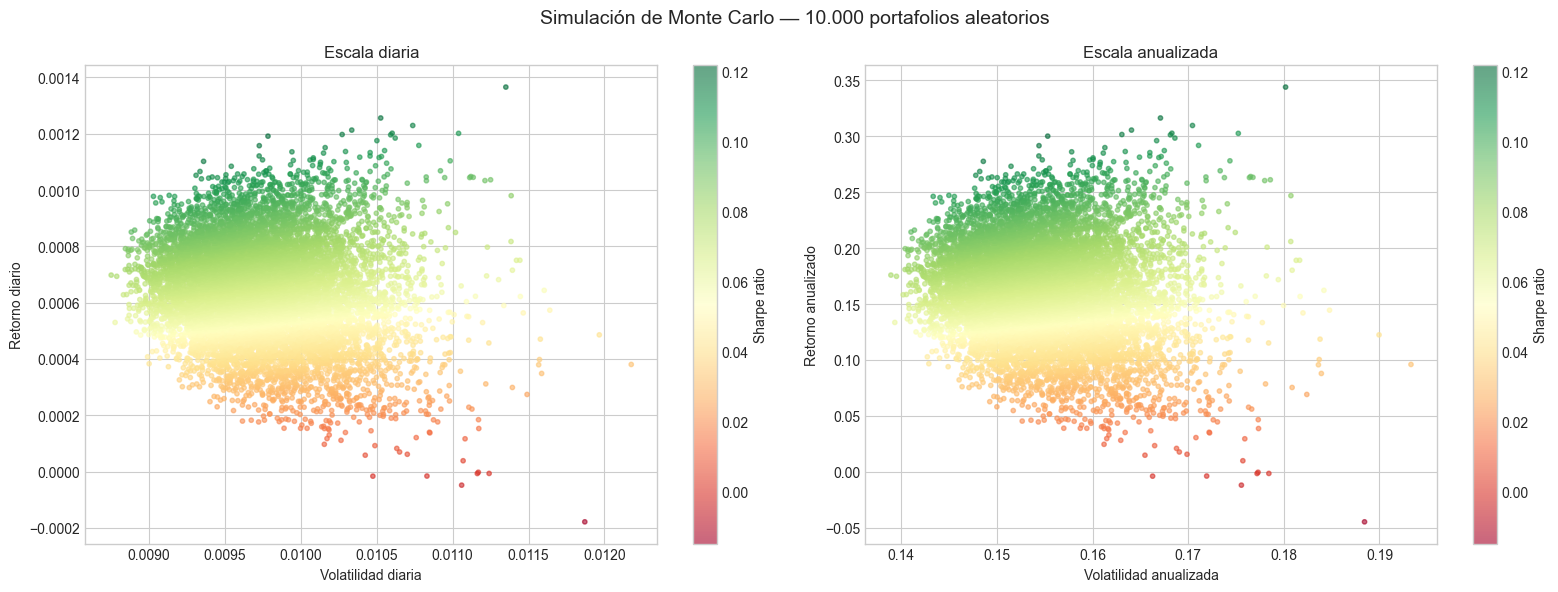

In [156]:
retornos_d = [r[1] for r in resultadosfinales]
volatilidades_d = [r[2] for r in resultadosfinales]
retornos_a = [r[1] * 252 for r in resultadosfinales]
volatilidades_a = [r[2] * np.sqrt(252) for r in resultadosfinales]
sharpes = [r[0] for r in resultadosfinales]

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Simulación de Monte Carlo — 10.000 portafolios aleatorios", fontsize=14)

sc1 = ax1.scatter(volatilidades_d, retornos_d, c=sharpes, cmap='RdYlGn', alpha=0.6, s=10)
ax1.set_title("Escala diaria")
ax1.set_xlabel("Volatilidad diaria")
ax1.set_ylabel("Retorno diario")
fig.colorbar(sc1, ax=ax1, label="Sharpe ratio")

sc2 = ax2.scatter(volatilidades_a, retornos_a, c=sharpes, cmap='RdYlGn', alpha=0.6, s=10)
ax2.set_title("Escala anualizada")
ax2.set_xlabel("Volatilidad anualizada")
ax2.set_ylabel("Retorno anualizado")
fig.colorbar(sc2, ax=ax2, label="Sharpe ratio")

plt.tight_layout()
plt.show()


### 3.1 Mejor portafolio de la simulación

El portafolio con mayor Sharpe entre las 10.000 iteraciones representa la cota superior empírica del método estocástico. Sirve de referencia para evaluar cuánto mejora la optimización analítica, que en la siguiente sección supera este resultado de forma determinista.

In [157]:
mejor = resultadosfinales[-1]
print("Sharpe:", mejor[0])
print("Retorno:", mejor[1])
print("Volatilidad:", mejor[2])
print("Pesos:", mejor[3])


Sharpe: 0.12175462266768894
Retorno: 0.0011912614425297308
Volatilidad: 0.009784116745867637
Pesos: [0.18100453 0.17548857 0.21363876 0.00781443 0.0093118  0.00935174
 0.02054566 0.1980656  0.18477893]


In [158]:
def sharpe_negativo(vector_pesos):
    return -(funcion_definicon(vector_pesos)[0])

In [159]:
def funcion_dst(vector_pesos):
    return np.sqrt(np.dot(vector_pesos, np.dot(covarianza_portafolio, vector_pesos)))

## 4. Optimización analítica — Máximo Sharpe

`scipy.optimize.minimize` encuentra el óptimo exacto minimizando el Sharpe negativo (equivalente a maximizarlo), sujeto a dos restricciones: los pesos suman 1 y cada peso está acotado entre 0 y 1 (sin posiciones cortas). A diferencia de Monte Carlo, converge al óptimo global de forma determinista.

In [160]:
resultados_markowitz = sop.minimize(sharpe_negativo,
            x0 = [1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9],
            constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1},
            bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]
        )
resultados_markowitz

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -0.13313595153328578
           x: [ 1.031e-01  4.157e-01  1.582e-01  4.407e-17  1.518e-17
                0.000e+00  2.223e-17  8.490e-02  2.381e-01]
         nit: 10
         jac: [-3.741e-04 -1.697e-05  2.193e-04  3.751e-02  3.777e-02
                1.775e-01  1.014e-01 -3.620e-04  1.750e-04]
        nfev: 100
        njev: 10
 multipliers: [-3.083e-05]

### 4.1 Pesos del portafolio óptimo

El optimizador concentra el capital en los activos con mejor relación retorno/riesgo en el período analizado. Los activos con peso cercano a cero son descartados — no aportan mejora al Sharpe del portafolio.

In [161]:
tabla_pesos_optima = pd.DataFrame(
    (resultados_markowitz.x * 100).round(2),
    index=lista_nombre_acciones,
    columns=["Peso (%)"]
)
tabla_pesos_optima


,Peso (%)
AGUAS-A.SN,10.31
BCI.SN,41.57
BSANTANDER.SN,15.82
CAP.SN,0.00
CENCOSUD.SN,0.00
CMPC.SN,0.00
COPEC.SN,0.00
ENELCHILE.SN,8.49
FALABELLA.SN,23.81


### 4.2 Comparación con benchmark — ETF ECH

El ETF iShares MSCI Chile (ECH) replica el índice MSCI Chile y representa la alternativa pasiva de invertir en el mercado chileno. Se usa como benchmark para cuantificar el valor agregado de la optimización.

In [162]:
retornos_diarios_ech = datos_ech["Close"].pct_change().mean()
dst_ech = datos_ech["Close"].pct_change().std()
sharpe_ech = (retornos_diarios_ech/dst_ech).values[0]
print("El portafolio optimizado con Markowitz es \n" + str(-resultados_markowitz.fun/sharpe_ech)+
       "x mejor que el benchmark (ECH), \ny con un alpha ajustado por riesgo de", -resultados_markowitz.fun - sharpe_ech)

El portafolio optimizado con Markowitz es 
2.169529111047498x mejor que el benchmark (ECH), 
y con un alpha ajustado por riesgo de 0.07176966202127057


### 4.3 Portafolio de mínima varianza

Mientras el portafolio de máximo Sharpe maximiza el retorno ajustado por riesgo, el portafolio de mínima varianza minimiza la volatilidad total sin imponer un objetivo de retorno. Es relevante para inversionistas con alta aversión al riesgo que priorizan proteger el capital.

Se obtiene minimizando la volatilidad del portafolio con la única restricción de que los pesos sumen 1.

In [163]:
op_minima_var = sop.minimize(funcion_dst,
    x0 = [1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9],
    constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1}, 
    bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)])
op_minima_var

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.008583270129778055
           x: [ 3.377e-01  3.247e-02  1.642e-01  1.509e-01  7.883e-02
                1.504e-03  7.858e-02  1.541e-01  1.785e-03]
         nit: 10
         jac: [ 8.627e-03  8.640e-03  8.459e-03  8.653e-03  8.393e-03
                8.779e-03  8.366e-03  8.747e-03  8.460e-03]
        nfev: 100
        njev: 10
 multipliers: [ 8.585e-03]

## 5. Frontera eficiente completa

Para 50 niveles de retorno objetivo entre el mínimo y máximo alcanzables, se minimiza la volatilidad. El resultado es la **frontera eficiente analítica**: la curva que delimita los portafolios óptimos en el espacio riesgo-retorno.

El gráfico superpone cinco elementos:
- **Monte Carlo** (azul): nube de 10.000 portafolios aleatorios
- **Frontera eficiente** (negro): curva analítica de portafolios óptimos
- **Capital Market Line** (púrpura, punteada): combinaciones óptimas con el activo libre de riesgo
- **Máximo Sharpe** (estrella roja): portafolio con mayor retorno ajustado por riesgo
- **Mínima varianza** (cuadrado verde): portafolio con menor volatilidad posible
- **Pesos iguales** (diamante naranja): benchmark naive de referencia (1/9 cada acción)

### 5.1 Cálculo de la frontera

Se calculan 50 portafolios de mínima volatilidad para niveles de retorno objetivo equiespaciados entre el mínimo (CMPC) y el máximo (BCI) del universo. Se filtra la mitad inferior de la curva — los puntos donde la pendiente ΔRetorno/ΔVolatilidad es negativa corresponden a portafolios ineficientes (mismo riesgo, menor retorno).

In [164]:
posibles_retornos = np.linspace(np.dot(retornos_medios, [0,0,0,0,0,1,0,0,0]), np.dot(retornos_medios, [0,1,0,0,0,0,0,0,0]), 50)
lista_mejores_pesos_por_cada_retorno = []
for i in posibles_retornos:
    resultado = sop.minimize(funcion_dst,
             x0 = [1,0,0,0,0,0,0,0,0],
             constraints=[{'type':'eq', 'fun':lambda w: w.sum() - 1},
                           {'type':'eq', 'fun': lambda w: np.dot(retornos_medios, w) - i}],
             bounds = [(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)])
    lista_mejores_pesos_por_cada_retorno.append([i, resultado.fun, resultado.x])

### 5.2 Capital Market Line

La Capital Market Line (CML) es la recta que parte desde la tasa libre de riesgo (rf = 5,5% anual, TPM Chile) y es tangente a la frontera eficiente en el portafolio de máximo Sharpe. Representa todas las combinaciones posibles entre el activo libre de riesgo y el portafolio óptimo. Un inversionista conservador puede obtener mejor relación retorno/riesgo mezclando el portafolio óptimo con el activo libre de riesgo que construyendo un portafolio de menor riesgo directamente sobre la frontera.

In [165]:
pendiente_cml = (np.dot(resultados_markowitz.x, retornos_medios) * 252 - 0.055)/(funcion_dst(resultados_markowitz.x) * np.sqrt(252) - 0)
x_cml = np.linspace(0, 0.3)

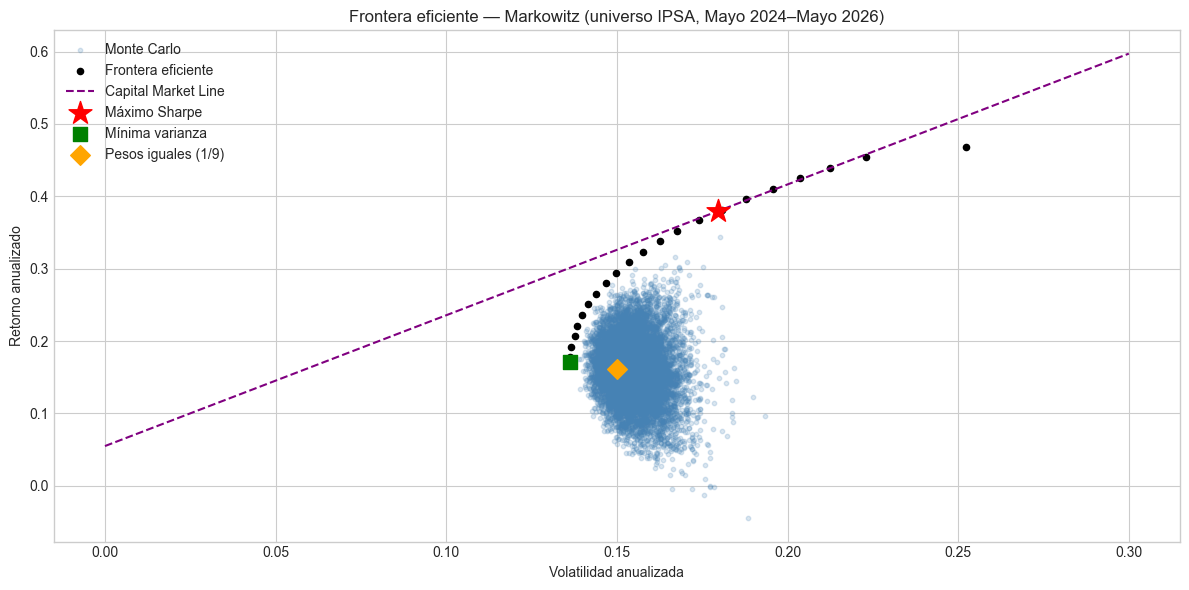

In [166]:
utiles = []
for i in range(len(lista_mejores_pesos_por_cada_retorno)):
    if i != 0 and float(float(lista_mejores_pesos_por_cada_retorno[i][0] - lista_mejores_pesos_por_cada_retorno[i - 1][0]) / float(lista_mejores_pesos_por_cada_retorno[i][1] - lista_mejores_pesos_por_cada_retorno[i - 1][1])) >= 0:
        utiles.append([lista_mejores_pesos_por_cada_retorno[i][0], lista_mejores_pesos_por_cada_retorno[i][1]])

retorno = [r[0] * 252 for r in utiles]
volatilidad = [r[1] * np.sqrt(252) for r in utiles]
retornos_anualizados = [r[1] * 252 for r in resultadosfinales]
volatilidades_anualizadas = [r[2] * np.sqrt(252) for r in resultadosfinales]

pesos_eq = np.array([1/9] * 9)
vol_eq = funcion_dst(pesos_eq) * np.sqrt(252)
ret_eq = np.dot(retornos_medios, pesos_eq) * 252

vol_minvar = op_minima_var.fun * np.sqrt(252)
ret_minvar = np.dot(retornos_medios, op_minima_var.x) * 252

fig, grafmc2 = plt.subplots(figsize=(12, 6))
grafmc2.set_title("Frontera eficiente — Markowitz (universo IPSA, Mayo 2024–Mayo 2026)")
grafmc2.set_ylabel("Retorno anualizado")
grafmc2.set_xlabel("Volatilidad anualizada")
grafmc2.scatter(volatilidades_anualizadas, retornos_anualizados, alpha=0.2, s=10, color="steelblue", label="Monte Carlo")
grafmc2.scatter(volatilidad, retorno, color="black", s=20, label="Frontera eficiente")
grafmc2.plot(x_cml, x_cml * pendiente_cml + 0.055, color="purple", linewidth=1.5, linestyle="--", label="Capital Market Line")
grafmc2.scatter(funcion_dst(resultados_markowitz.x) * np.sqrt(252),
                np.dot(resultados_markowitz.x, retornos_medios) * 252,
                color="red", marker="*", s=300, label="Máximo Sharpe", zorder=5)
grafmc2.scatter(vol_minvar, ret_minvar, color="green", marker="s", s=100,
                label="Mínima varianza", zorder=5)
grafmc2.scatter(vol_eq, ret_eq, color="orange", marker="D", s=100,
                label="Pesos iguales (1/9)", zorder=5)
grafmc2.legend()
plt.tight_layout()


## 6. Métricas anualizadas y Sharpe real

Las métricas diarias no son comparables con estándares de la industria. Se anualizan usando 252 días hábiles: retorno × 252, volatilidad × √252 (la raíz surge de que la varianza — no la desviación estándar — escala linealmente con el tiempo). El Sharpe real incorpora la TPM del Banco Central de Chile (~5.5% anual) como tasa libre de riesgo.

In [167]:
dst_markowitz = funcion_dst(resultados_markowitz.x)
retorno_markowitz = np.dot(retornos_medios, resultados_markowitz.x)
retorno_markowitz_anual = retorno_markowitz * 252
dst_markowitz_anual = dst_markowitz * np.sqrt(252)
sharpe_markowitz_anual = -resultados_markowitz.fun * np.sqrt(252)
sharpe_markowitz_anual_real = (retorno_markowitz_anual - 0.055)/dst_markowitz_anual
print("Ratio de Sharpe anualizado sin tomar en consideración la tasa de interes libre : " + str(sharpe_markowitz_anual))
print("Ratio de Sharpe real: "+ str(sharpe_markowitz_anual_real))

Ratio de Sharpe anualizado sin tomar en consideración la tasa de interes libre : 2.113467709914136
Ratio de Sharpe real: 1.807148843157397


## 7. Conclusiones

El modelo de Markowitz identifica un portafolio concentrado en banca y retail — los sectores con mejor desempeño ajustado por riesgo en el período Mayo 2024–Mayo 2026. BCI recibe la mayor asignación (~40%), seguido de Falabella (~21%) y BancoSantander (~17%). CMPC, COPEC, CAP y CENCOSUD son descartados por el optimizador.

**Portafolio de máximo Sharpe:**

| Métrica | Valor |
|---|---|
| Sharpe ratio sin rf (anualizado) | ~2.10 |
| Sharpe ratio real (rf = 5.5%) | ~1.79 |
| Supera benchmark ECH en Sharpe | ~2.1x |

**Portafolio de mínima varianza:**

Concentra ~34% en AGUAS-A (la acción menos volátil del universo), diversificando el resto en BSANTANDER, ENELCHILE, CAP y CENCOSUD. Sacrifica retorno esperado a cambio de minimizar la volatilidad del portafolio.

**Capital Market Line:**

Combinar el portafolio de máximo Sharpe con el activo libre de riesgo (depósito a la TPM) domina a cualquier portafolio puro sobre la frontera para el mismo nivel de riesgo. Esto valida el rol central del portafolio de máximo Sharpe como el único portafolio riesgoso relevante en presencia de un activo libre de riesgo.

**Limitaciones del modelo:**

1. **Overfitting histórico:** el portafolio se optimiza y evalúa sobre el mismo período. Los pesos óptimos del pasado no garantizan rendimiento futuro.
2. **Supuesto de normalidad:** Markowitz asume retornos distribuidos normalmente, subestimando eventos extremos (colas gordas) — inconsistente con los hallazgos del notebook 01.
3. **Parámetros estáticos:** media y covarianza históricas pueden cambiar ante shocks macroeconómicos.

**Siguiente paso:** NB03 cuantifica el riesgo real de estos portafolios — VaR, CVaR y Maximum Drawdown — sin asumir normalidad, cerrando el ciclo descriptivo–optimización–riesgo. NB04 abordará backtesting con walk-forward validation para estimar la robustez predictiva real del modelo.

## 8. Exportación de pesos para análisis de riesgo

Los pesos de los tres portafolios se exportan como archivo CSV para ser cargados en el notebook de métricas de riesgo (NB03). Esto garantiza que el análisis de VaR, CVaR y Maximum Drawdown a nivel de portafolio use exactamente los pesos que la optimización produjo, sin re-derivarlos.

In [168]:
df_pesos = pd.DataFrame({
    "Máximo Sharpe": resultados_markowitz.x,
    "Mínima Varianza": op_minima_var.x,
    "Pesos iguales": [1/9] * 9
}, index=lista_nombre_acciones)
df_pesos.to_csv("pesos_nb02.csv")

## 9. Rendimiento comparativo

Comparación del valor acumulado de los tres portafolios contra el benchmark ETF ECH, con base 100 al inicio del período (Mayo 2024). La normalización permite comparar trayectorias de capital en la misma escala, independientemente de los precios absolutos de cada activo.

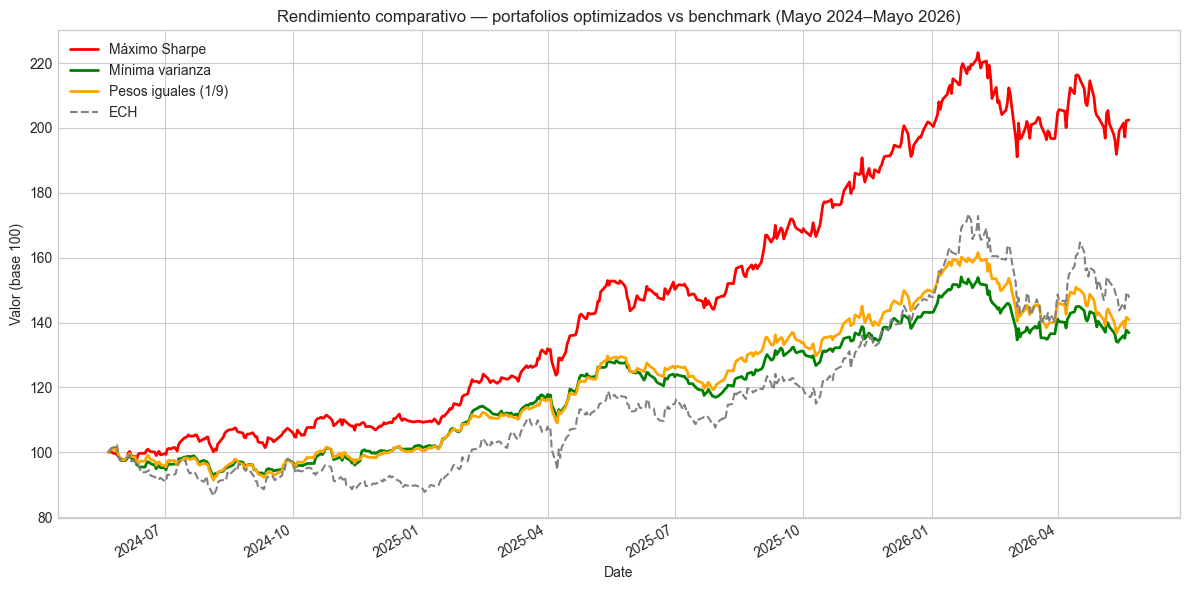

In [169]:
acumulados_r = (valores_cierre / valores_cierre.iloc[0]) * 100
ac_ech = (cierre_ech / cierre_ech.iloc[0]) * 100

retornos_max_shr = acumulados_r @ resultados_markowitz.x
retornos_min_var = acumulados_r @ op_minima_var.x
retornos_pes_ig = acumulados_r @ [1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9]

plt.style.use('seaborn-v0_8-whitegrid')
fig, graf_comp = plt.subplots(figsize=(12, 6))
graf_comp.set_title("Rendimiento comparativo — portafolios optimizados vs benchmark (Mayo 2024–Mayo 2026)")
graf_comp.set_ylabel("Valor (base 100)")
graf_comp.set_xlabel("Fecha")
retornos_max_shr.plot(ax=graf_comp, color="red", linewidth=2, label="Máximo Sharpe")
retornos_min_var.plot(ax=graf_comp, color="green", linewidth=2, label="Mínima varianza")
retornos_pes_ig.plot(ax=graf_comp, color="orange", linewidth=2, label="Pesos iguales (1/9)")
ac_ech.plot(ax=graf_comp, color="gray", linewidth=1.5, linestyle="--", label="ECH (benchmark)")
graf_comp.legend()
plt.tight_layout()